# Timepix 事件数据批量统计（仅激活像素）

本 Notebook 用于对**按角度子文件夹组织**的 Timepix/探测器事件数据进行批量分析：

- 每个事件为一个 `.txt` 文件，内部为 `100×100` 矩阵（空格分隔、6位小数）
- **仅对激活像素（value > 0）**计算事件级统计量
- 轨迹外切矩形长宽比采用 **`max(width, height) / min(width, height)`**
- 面向大数据量：流式处理、分批写出、可选并行、可跳过已处理结果

你需要做的唯一必改项：把第 1 节里的 `DATA_ROOT` 改成你的数据总目录。

In [18]:
# 1) 运行参数（路径占位、输出目录、并行度）
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import math
import time
import json
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# 可选增强：tqdm / seaborn（缺失则自动降级）
try:
    from tqdm.auto import tqdm  # type: ignore
except Exception:
    tqdm = None  # type: ignore

try:
    import seaborn as sns  # type: ignore
    _HAS_SEABORN = True
except Exception:
    sns = None  # type: ignore
    _HAS_SEABORN = False


@dataclass(frozen=True)
class RunConfig:
    # TODO: 这里留空/占位，你稍后自行修改为你的数据总目录
    DATA_ROOT: Path = Path(r"E:\C1Analysis\C84")
    # 输出目录（会自动创建）
    OUT_DIR: Path = Path(r"E:\C1Analysis\C84_analysis_output")

    # 事件文件模式（每个文件=一个事件）
    EVENT_GLOB: str = "*.txt"
    RECURSIVE: bool = False  # 若角度目录下还有多级子目录，可改 True
    MATRIX_SHAPE: tuple[int, int] = (100, 100)

    # 激活像素判定阈值：仅对 active_values 计算统计量
    ACTIVE_THRESHOLD: float = 0.0

    # 性能：分批写出与日志
    BATCH_SIZE: int = 2048
    STOP_AFTER_N_BATCHES: int | None = None  # 调试用：只跑前 N 个 batch
    SKIP_IF_OUTPUT_EXISTS: bool = True

    # 并行（Windows + Notebook 下建议先单进程验证，再开并行）
    USE_PARALLEL: bool = False
    N_WORKERS: int = max(1, (os.cpu_count() or 4) - 1)
    # 并行模式下：每个任务处理多少文件（减少进程调度开销）
    FILES_PER_TASK: int = 32

    # 绘图（大数据量时仅抽样绘图，避免内存爆）
    MAX_PLOT_POINTS: int = 200_000
    PLOT_DPI: int = 220
    SAVE_PDF: bool = True


CFG = RunConfig()

# ---- 打印关键参数，确保可复现 ----
print("CWD:", os.getcwd())
print("DATA_ROOT:", CFG.DATA_ROOT)
print("OUT_DIR:", CFG.OUT_DIR.resolve())
print("EVENT_GLOB:", CFG.EVENT_GLOB, "RECURSIVE:", CFG.RECURSIVE)
print("ACTIVE_THRESHOLD:", CFG.ACTIVE_THRESHOLD)
print("BATCH_SIZE:", CFG.BATCH_SIZE, "USE_PARALLEL:", CFG.USE_PARALLEL, "N_WORKERS:", CFG.N_WORKERS)
print("MAX_PLOT_POINTS:", CFG.MAX_PLOT_POINTS)

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)

# 科研绘图风格（无 seaborn 也可用）
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "savefig.dpi": CFG.PLOT_DPI,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
if _HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="paper")

CWD: d:\Project\Timepix\ProcessData\Program
DATA_ROOT: E:\C1Analysis\C84
OUT_DIR: E:\C1Analysis\C84_analysis_output
EVENT_GLOB: *.txt RECURSIVE: False
ACTIVE_THRESHOLD: 0.0
BATCH_SIZE: 2048 USE_PARALLEL: False N_WORKERS: 19
MAX_PLOT_POINTS: 200000


## 2. 文件扫描：每个文件 = 一个事件（增量遍历与排序）

假设目录结构类似：

```
DATA_ROOT/
  15/   # 角度
    xxx.txt
    yyy.txt
  30/
    ...
```

本节会扫描 `DATA_ROOT` 下的一级子目录作为“角度”，并枚举其中的事件 txt 文件。

In [19]:
def iter_angle_dirs(data_root: Path) -> list[Path]:
    """返回 DATA_ROOT 下的角度目录列表（仅一级子目录）。"""
    if not data_root.exists():
        raise FileNotFoundError(f"DATA_ROOT 不存在：{data_root}")
    angle_dirs = [p for p in data_root.iterdir() if p.is_dir()]
    # 轻量排序：按名称（通常是角度数值字符串）
    angle_dirs.sort(key=lambda p: p.name)
    return angle_dirs


def iter_event_files(angle_dir: Path, pattern: str, recursive: bool) -> list[Path]:
    """枚举角度目录下事件文件。默认返回 list（便于计数/并行）。"""
    if recursive:
        files = list(angle_dir.rglob(pattern))
    else:
        files = list(angle_dir.glob(pattern))
    files = [p for p in files if p.is_file()]
    # 轻量排序：按文件名（避免额外 stat 开销）
    files.sort(key=lambda p: p.name)
    return files


def preview_scan():
    angle_dirs = iter_angle_dirs(CFG.DATA_ROOT)
    print(f"角度目录数量: {len(angle_dirs)}")
    if angle_dirs:
        print("示例角度目录:")
        for p in angle_dirs[:5]:
            print(" -", p.name, "->", p)
            files = iter_event_files(p, CFG.EVENT_GLOB, CFG.RECURSIVE)
            print("   事件文件数:", len(files))
            for f in files[:3]:
                print("   ", f.name)


# 取消下一行注释以预览扫描结果（先把 DATA_ROOT 改对）
# preview_scan()

## 3. 高性能读入：文本矩阵按需读取与类型优化

你的事件是文本矩阵。为了性能：

- 使用 `np.fromstring(text, sep=' ')` 解析（通常比 `np.loadtxt` 更快）
- dtype 使用 `float32`（足够精度且更省内存）
- 仅在需要时 reshape 为 `100×100`

注意：若数据中存在多余空行/不规则空格，`fromstring` 依然可容错。

In [20]:
def read_event_txt_fast(file_path: Path, shape: tuple[int, int] = (100, 100), dtype=np.float32) -> np.ndarray:
    """高性能读取单个事件 txt -> 2D ndarray。"""
    # 读取为字符串后一次性解析（100x100=10000 个数，规模固定）
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    data = np.fromstring(text, sep=" ", dtype=dtype)
    expected = shape[0] * shape[1]
    if data.size != expected:
        # 某些文件可能有额外空格/换行不影响 size，但若确实不匹配则报错
        raise ValueError(f"文件 {file_path} 数值数量异常：{data.size} != {expected}")
    return data.reshape(shape)

## 4. 事件像素筛选：仅对激活像素计算（稀疏索引/掩码）

激活规则：`value > ACTIVE_THRESHOLD`。

无激活像素事件：统计量记为 `NaN`（计数为 0），并在汇总里单独统计。

In [21]:
def compute_event_features(frame: np.ndarray, active_threshold: float = 0.0) -> dict:
    """仅对激活像素计算事件特征。"""
    # 激活掩码
    mask = frame > active_threshold
    active_count = int(mask.sum())
    if active_count == 0:
        return {
            "active_count": 0,
            "bbox_aspect_ratio": np.nan,
            "active_sum": np.nan,
            "active_mean": np.nan,
            "active_var": np.nan,
            "active_min": np.nan,
            "active_max": np.nan,
        }

    # 激活值（1D）
    active_values = frame[mask]

    # bbox：用 nonzero 得到坐标（比 argwhere 少一次堆叠）
    rows, cols = np.nonzero(mask)
    r0, r1 = int(rows.min()), int(rows.max())
    c0, c1 = int(cols.min()), int(cols.max())
    height = (r1 - r0) + 1
    width = (c1 - c0) + 1
    bbox_aspect_ratio = float(max(width, height) / max(1, min(width, height)))

    # 仅激活像素统计量
    active_sum = float(active_values.sum())
    active_mean = float(active_values.mean())
    active_var = float(active_values.var(ddof=0))
    active_min = float(active_values.min())
    active_max = float(active_values.max())

    return {
        "active_count": active_count,
        "bbox_aspect_ratio": bbox_aspect_ratio,
        "active_sum": active_sum,
        "active_mean": active_mean,
        "active_var": active_var,
        # 额外：min/max（对激活像素）——便于后续做 max/min 归一化或幅度分析
        "active_min": active_min,
        "active_max": active_max,
    }

## 5. Max/Min 方式特征/归一化：按事件在激活像素上计算

你当前明确要求的 `max/min` 用于 **bbox 长宽比**。另外这里也补充了激活像素的 `active_min/active_max`，常用于后续：

$$x' = \frac{x-\min}{\max-\min+\epsilon}$$

注意：本 Notebook 默认不保存归一化后的整帧（会非常大），只保存事件级汇总特征。

In [22]:
def normalize_active_values(active_values: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """对激活像素做 max-min 归一化（返回 1D）。"""
    if active_values.size == 0:
        return active_values
    vmin = active_values.min()
    vmax = active_values.max()
    return (active_values - vmin) / (vmax - vmin + eps)

## 6. 批处理与流式写出：避免一次性载入（CSV）

输出策略：

- 每个角度输出一个事件级表：`features_<angle>.csv`
- 角度级汇总输出：`angle_summary.csv`

事件级 CSV 的列：
`file, active_count, bbox_aspect_ratio, active_sum, active_mean, active_var, active_min, active_max`

In [23]:
def angle_out_paths(angle_name: str) -> dict[str, Path]:
    angle_dir = CFG.OUT_DIR / f"angle={angle_name}"
    angle_dir.mkdir(parents=True, exist_ok=True)
    return {
        "dir": angle_dir,
        "features_csv": angle_dir / f"features_{angle_name}.csv",
        "plots_dir": angle_dir / "plots",
    }


def append_batch_to_csv(csv_path: Path, rows: list[dict]):
    if not rows:
        return
    df = pd.DataFrame.from_records(rows)
    header = not csv_path.exists()
    df.to_csv(csv_path, mode="a", index=False, header=header)


def process_angle_sequential(angle_dir: Path) -> dict:
    angle_name = angle_dir.name
    out = angle_out_paths(angle_name)
    out["plots_dir"].mkdir(parents=True, exist_ok=True)

    features_csv = out["features_csv"]
    if CFG.SKIP_IF_OUTPUT_EXISTS and features_csv.exists():
        return {"angle": angle_name, "skipped": True, "features_csv": str(features_csv)}

    files = iter_event_files(angle_dir, CFG.EVENT_GLOB, CFG.RECURSIVE)
    t0 = time.perf_counter()

    rows: list[dict] = []
    n_batches = 0
    n_errors = 0

    it = files
    if tqdm is not None:
        it = tqdm(files, desc=f"angle={angle_name}", leave=False)  # type: ignore

    for i, fp in enumerate(it):
        try:
            frame = read_event_txt_fast(fp, shape=CFG.MATRIX_SHAPE)
            feat = compute_event_features(frame, active_threshold=CFG.ACTIVE_THRESHOLD)
            feat["file"] = fp.name
            rows.append(feat)
        except Exception as e:
            n_errors += 1
            # 记录错误但不中断
            rows.append({"file": fp.name, "error": str(e)})

        if len(rows) >= CFG.BATCH_SIZE:
            append_batch_to_csv(features_csv, rows)
            rows.clear()
            n_batches += 1
            if CFG.STOP_AFTER_N_BATCHES is not None and n_batches >= CFG.STOP_AFTER_N_BATCHES:
                break

    if rows:
        append_batch_to_csv(features_csv, rows)
        rows.clear()

    dt = time.perf_counter() - t0
    return {
        "angle": angle_name,
        "skipped": False,
        "features_csv": str(features_csv),
        "n_files": len(files),
        "n_errors": n_errors,
        "seconds": dt,
        "events_per_sec": (len(files) / dt) if dt > 0 else np.nan,
    }

## 7. 并行与性能优化：进程池、批大小、I/O 合并

说明：

- 并行对“很多小文件”的吞吐可能提升明显，但 Windows 下进程启动/序列化有开销
- 建议先单进程跑通一个小角度目录，再把 `USE_PARALLEL=True`
- 并行时每个任务处理 `FILES_PER_TASK` 个文件，减少调度开销

In [24]:
from concurrent.futures import ProcessPoolExecutor, as_completed


def _process_files_task(file_paths: list[str], shape: tuple[int, int], active_threshold: float) -> list[dict]:
    """子进程任务：读取一批文件并返回轻量特征列表。"""
    rows: list[dict] = []
    for p in file_paths:
        fp = Path(p)
        try:
            frame = read_event_txt_fast(fp, shape=shape)
            feat = compute_event_features(frame, active_threshold=active_threshold)
            feat["file"] = fp.name
            rows.append(feat)
        except Exception as e:
            rows.append({"file": fp.name, "error": str(e)})
    return rows


def process_angle_parallel(angle_dir: Path) -> dict:
    angle_name = angle_dir.name
    out = angle_out_paths(angle_name)
    out["plots_dir"].mkdir(parents=True, exist_ok=True)

    features_csv = out["features_csv"]
    if CFG.SKIP_IF_OUTPUT_EXISTS and features_csv.exists():
        return {"angle": angle_name, "skipped": True, "features_csv": str(features_csv)}

    files = iter_event_files(angle_dir, CFG.EVENT_GLOB, CFG.RECURSIVE)
    file_strs = [str(p) for p in files]

    # 分块
    chunks: list[list[str]] = []
    step = max(1, CFG.FILES_PER_TASK)
    for i in range(0, len(file_strs), step):
        chunks.append(file_strs[i:i+step])

    t0 = time.perf_counter()
    n_errors = 0
    written = 0

    pbar_total = len(chunks)
    pbar = None
    if tqdm is not None:
        pbar = tqdm(total=pbar_total, desc=f"angle={angle_name} (parallel)", leave=False)  # type: ignore

    with ProcessPoolExecutor(max_workers=CFG.N_WORKERS) as ex:
        futures = [ex.submit(_process_files_task, ch, CFG.MATRIX_SHAPE, CFG.ACTIVE_THRESHOLD) for ch in chunks]
        buffer_rows: list[dict] = []
        for fut in as_completed(futures):
            rows = fut.result()
            # 统计 error 行
            for r in rows:
                if "error" in r:
                    n_errors += 1
            buffer_rows.extend(rows)
            if len(buffer_rows) >= CFG.BATCH_SIZE:
                append_batch_to_csv(features_csv, buffer_rows)
                written += len(buffer_rows)
                buffer_rows.clear()
            if pbar is not None:
                pbar.update(1)  # type: ignore

        if buffer_rows:
            append_batch_to_csv(features_csv, buffer_rows)
            written += len(buffer_rows)
            buffer_rows.clear()

    if pbar is not None:
        pbar.close()  # type: ignore

    dt = time.perf_counter() - t0
    return {
        "angle": angle_name,
        "skipped": False,
        "features_csv": str(features_csv),
        "n_files": len(files),
        "n_errors": n_errors,
        "written_rows": written,
        "seconds": dt,
        "events_per_sec": (len(files) / dt) if dt > 0 else np.nan,
    }

## 8. 基于 CSV 的统计与绘图（推荐工作流）

你希望的工作流是：

1) **先生成一次事件级 CSV**（耗时，但只需做一次或增量补齐）
2) **反复调整绘图参数**时，只读取既有 CSV（不重复计算特征）并在 Notebook 内直接展示图
3) 参数满意后，再**把图保存到文件**（PNG/PDF）

下面的代码会提供：

- 角度级统计摘要（从 CSV 读取，可重复执行）
- 交互式绘图：默认只 `plt.show()`，不保存
- 最终保存：单独函数执行保存

性能说明（数据量大时）：

- 绘图默认对每个角度最多抽样 `SAMPLE_MAX_POINTS` 条事件进入内存并缓存，后续重绘基本不耗时
- 如果你改了抽样数/过滤规则，可用 `refresh_data=True` 重新加载缓存

In [25]:
@dataclass(frozen=True)
class PlotConfig:
    # ========== 数据读取/抽样（影响性能与内存） ==========
    # 每个角度用于绘图的最大事件数（会随机抽样）。越大越准，但越占内存/越慢。
    SAMPLE_MAX_POINTS: int = 200_000
    # 随机种子（保证多次抽样结果可复现）
    RANDOM_STATE: int = 42
    # 是否丢弃“无激活像素事件”（active_count==0）。True 更聚焦轨迹事件，False 可观察空事件占比。
    DROP_EMPTY_EVENTS: bool = True

    # ========== 图形外观（你主要会调这里） ==========
    # 每张图尺寸（英寸）
    FIGSIZE: tuple[float, float] = (7.2, 4.2)
    # 直方图 bins：可用整数（如 60）或 matplotlib 支持的字符串（如 "auto"）
    BINS: int | str = "auto"
    # 是否叠加 KDE 平滑曲线（需要安装 seaborn；数据量太大时建议 False）
    SHOW_KDE: bool = False
    # 颜色（科研风格：推荐深色主色 + 白色边）
    COLOR: str = "#1f77b4"
    EDGE_COLOR: str = "white"
    EDGE_LINEWIDTH: float = 0.4
    ALPHA: float = 0.95
    # 标题模板（{angle}、{label}、{n} 可用）
    TITLE_TEMPLATE: str = "Angle={angle} | {label} (n={n})"

    # ========== 横坐标范围控制（解决你说的“范围太广”） ==========
    # 方式 1（推荐）：按分位裁剪数据范围，再画直方图。
    #   例如 (0.01, 0.99) 会去掉最小 1% 和最大 1% 的极端值，让主要分布更“铺满”横轴。
    #   设置为 None 表示不按分位裁剪。
    CLIP_QUANTILES: tuple[float, float] | None = (0.001, 0.999)

    # 方式 2：手动指定某些指标的 x 轴范围（更直接）。
    #   写法：(("active_count", 0, 4000), ("active_sum", 0, 20000), ...)
    #   未指定的指标仍使用默认范围（或 CLIP_QUANTILES）。
    XLIMS: tuple[tuple[str, float, float], ...] = ()

    # 是否对 x 轴使用对数坐标（适合强长尾，如 active_sum）。注意：对数坐标要求 x>0。
    LOGX_FEATURES: tuple[str, ...] = ()
    # 是否对 y 轴使用对数坐标（数量跨度很大时可开）
    LOGY: bool = False

    # ========== 输出（最终保存时使用；调参阶段 show 不保存） ==========
    SAVE_DPI: int = 260
    SAVE_PDF: bool = True


PLOT_CFG = PlotConfig()

print("PLOT_CFG =", PLOT_CFG)

PLOT_CFG = PlotConfig(SAMPLE_MAX_POINTS=200000, RANDOM_STATE=42, DROP_EMPTY_EVENTS=True, FIGSIZE=(7.2, 4.2), BINS='auto', SHOW_KDE=False, COLOR='#1f77b4', EDGE_COLOR='white', EDGE_LINEWIDTH=0.4, ALPHA=0.95, TITLE_TEMPLATE='Angle={angle} | {label} (n={n})', CLIP_QUANTILES=(0.001, 0.999), XLIMS=(), LOGX_FEATURES=(), LOGY=False, SAVE_DPI=260, SAVE_PDF=True)


### 绘图参数（中文，建议你只改这里）

下面这组参数专门用于“**基于 CSV 重绘**”。你可以反复修改并多次运行绘图函数，**不会重新计算特征，也不会覆盖 CSV**。

提示：若你只改 `bins/标题/颜色/坐标轴范围/是否对数坐标` 等绘图参数，不需要刷新数据缓存。只有当你改了“抽样数量/过滤规则”才建议 `refresh_data=True`。

In [26]:
FEATURE_COLUMNS = [
    "active_count",
    "bbox_aspect_ratio",
    "active_sum",
    "active_mean",
    "active_var",
    "active_min",
    "active_max",
]

# 用于展示的指标（你可按需增删）
PLOT_ITEMS: list[tuple[str, str]] = [
    ("active_count", "激活像素个数"),
    ("bbox_aspect_ratio", "外切矩形长宽比 (max/min)"),
    ("active_sum", "激活像素值求和"),
    ("active_mean", "激活像素值均值"),
    # ("active_var", "激活像素值方差"),  # 如需也画方差，取消注释
    # ("active_min", "激活像素最小值"),
    # ("active_max", "激活像素最大值"),
]

# -------- CSV -> DataFrame 抽样缓存（用于快速重绘） --------
# key 设计：角度 + 抽样上限 + 是否丢弃空事件（其它绘图参数变化不影响缓存）
_PLOT_DATA_CACHE: dict[tuple[str, int, bool], pd.DataFrame] = {}

# 最近一次 OUT_DIR 搜索路径（用于报错提示）
_LAST_OUTDIR_CANDIDATES: list[Path] = []


def _unique_existing_paths(paths: list[Path]) -> list[Path]:
    seen = set()
    out: list[Path] = []
    for p in paths:
        try:
            rp = p.resolve()
        except Exception:
            rp = p
        key = str(rp).lower()
        if key in seen:
            continue
        seen.add(key)
        out.append(rp)
    return [p for p in out if p.exists()]


def _out_dir_candidates(out_dir: Path) -> list[Path]:
    """生成可能的 OUT_DIR 候选路径。

    解决常见问题：CFG.OUT_DIR 是相对路径时，Notebook 的当前工作目录 (CWD) 不同会导致找不到 CSV。
    本函数会在 CWD 的各级父目录下尝试拼接 out_dir，直到找到真实输出目录。
    """
    cands: list[Path] = []
    if out_dir.is_absolute():
        cands.append(out_dir)
        return _unique_existing_paths(cands)

    # 1) 直接使用（相对 CWD）
    cands.append(out_dir)
    # 2) CWD/out_dir
    cands.append(Path.cwd() / out_dir)
    # 3) CWD 的各级父目录 / out_dir（最常用：找到仓库根目录再拼）
    for p in [Path.cwd(), *Path.cwd().parents]:
        cands.append(p / out_dir)
    # 4) 兜底：如果 out_dir 末尾就是 '_angle_batch_out'，也尝试在父目录里直接找这个目录
    tail = out_dir.parts[-1] if out_dir.parts else str(out_dir)
    if tail:
        for p in [Path.cwd(), *Path.cwd().parents]:
            cands.append(p / tail)
    return _unique_existing_paths(cands)


def _infer_angle_name_from_csv_path(csv_path: Path) -> str:
    # 优先找 'angle=XX' 这种目录名（即使 CSV 在更深层子目录）
    for part in reversed(csv_path.parts):
        if part.startswith("angle="):
            return part.replace("angle=", "", 1)
    # 否则：用 CSV 的父目录名作为角度名
    return csv_path.parent.name


def list_existing_angle_csvs(out_dir: Path) -> dict[str, Path]:
    """扫描 OUT_DIR 下已生成的 features_*.csv，用于仅绘图场景（不依赖 DATA_ROOT）。

    说明：CSV 可能位于 angle 子文件夹中（例如 out/angle=15/features_15.csv）。
    本函数会递归搜索，并自动解析角度名。
    """
    global _LAST_OUTDIR_CANDIDATES
    angle_map: dict[str, Path] = {}
    candidates = _out_dir_candidates(out_dir)
    _LAST_OUTDIR_CANDIDATES = candidates

    if not candidates:
        return angle_map

    for base in candidates:
        # 快速路径：符合默认输出结构
        for p in base.glob("angle=*/features_*.csv"):
            if p.is_file():
                angle_map[_infer_angle_name_from_csv_path(p)] = p
        if angle_map:
            continue

        # 兜底：递归搜（兼容你手动改过输出结构、或 CSV 在更深层）
        for p in base.rglob("features_*.csv"):
            if p.is_file():
                angle_map[_infer_angle_name_from_csv_path(p)] = p

    # 轻量排序：按角度名
    return dict(sorted(angle_map.items(), key=lambda kv: kv[0]))


def load_features_sample(csv_path: Path, *, max_points: int, random_state: int, drop_empty_events: bool) -> pd.DataFrame:
    """从 CSV 抽样到内存（尽量快）。用于绘图，避免每次重读大文件。"""
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)

    # 尝试读文件大小，小于阈值就全量读入
    try:
        size_mb = csv_path.stat().st_size / (1024 * 1024)
    except Exception:
        size_mb = None

    usecols = lambda c: c in (FEATURE_COLUMNS + ["file", "error"])  # noqa: E731
    if size_mb is not None and size_mb < 120:
        df = pd.read_csv(csv_path, usecols=usecols)
        if "error" in df.columns:
            df = df[df["error"].isna()].copy()
        if drop_empty_events and "active_count" in df.columns:
            df = df[df["active_count"] > 0].copy()
        return df

    # 大文件：分块读 + reservoir-like 抽样（近似均匀，足够用于分布图）
    rng = np.random.default_rng(random_state)
    sample_df: pd.DataFrame | None = None
    chunk_size = 200_000

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunk_size):
        if "error" in chunk.columns:
            chunk = chunk[chunk["error"].isna()]
        if drop_empty_events and "active_count" in chunk.columns:
            chunk = chunk[chunk["active_count"] > 0]
        if chunk.empty:
            continue

        if sample_df is None:
            # 初始化：若首块已超过 max_points，直接抽样到 max_points
            if len(chunk) > max_points:
                sample_df = chunk.sample(n=max_points, random_state=random_state)
            else:
                sample_df = chunk.copy()
            continue

        # 合并后若超出 max_points，则再抽样回 max_points
        sample_df = pd.concat([sample_df, chunk], ignore_index=True)
        if len(sample_df) > max_points:
            seed = int(rng.integers(0, 2**31 - 1))
            sample_df = sample_df.sample(n=max_points, random_state=seed)

    if sample_df is None:
        return pd.DataFrame(columns=(FEATURE_COLUMNS + ["file"]))
    return sample_df


def get_plot_df(angle_name: str, csv_path: Path, *, refresh_data: bool = False) -> pd.DataFrame:
    """获取某角度用于绘图的 DataFrame（带缓存）。"""
    cache_key = (angle_name, PLOT_CFG.SAMPLE_MAX_POINTS, PLOT_CFG.DROP_EMPTY_EVENTS)
    if (not refresh_data) and (cache_key in _PLOT_DATA_CACHE):
        return _PLOT_DATA_CACHE[cache_key]

    df = load_features_sample(
        csv_path,
        max_points=PLOT_CFG.SAMPLE_MAX_POINTS,
        random_state=PLOT_CFG.RANDOM_STATE,
        drop_empty_events=PLOT_CFG.DROP_EMPTY_EVENTS,
    )
    _PLOT_DATA_CACHE[cache_key] = df
    return df


def summarize_angle(csv_path: Path, angle_name: str) -> dict:
    """角度级统计摘要：从 CSV 读取（可反复运行）。"""
    usecols = lambda c: c in (FEATURE_COLUMNS + ["file", "error"])  # noqa: E731
    df = pd.read_csv(csv_path, usecols=usecols)
    if "error" in df.columns:
        df_ok = df[df["error"].isna()].copy()
    else:
        df_ok = df.copy()

    n_total = len(df)
    n_ok = len(df_ok)
    n_empty = int((df_ok["active_count"] == 0).sum()) if n_ok and ("active_count" in df_ok.columns) else 0
    empty_ratio = (n_empty / n_ok) if n_ok else np.nan

    desc = df_ok[FEATURE_COLUMNS].describe(percentiles=[0.25, 0.5, 0.75]).to_dict()
    return {
        "angle": angle_name,
        "n_total_rows": n_total,
        "n_ok_rows": n_ok,
        "n_error_rows": n_total - n_ok,
        "n_empty_events": n_empty,
        "empty_ratio": empty_ratio,
        "describe": desc,
    }


def build_angle_summary(*, save_csv: bool = True) -> pd.DataFrame:
    """扫描 OUT_DIR 中已存在的 CSV，生成角度级 summary 表。"""
    angle_map = list_existing_angle_csvs(CFG.OUT_DIR)
    rows = []
    for angle_name, csv_path in angle_map.items():
        try:
            summ = summarize_angle(csv_path, angle_name)
            rows.append({
                "angle": summ["angle"],
                "n_ok_rows": summ["n_ok_rows"],
                "n_error_rows": summ["n_error_rows"],
                "n_empty_events": summ["n_empty_events"],
                "empty_ratio": summ["empty_ratio"],
            })
        except Exception as e:
            rows.append({"angle": angle_name, "error": str(e)})

    summary_df = pd.DataFrame(rows).sort_values("angle") if rows else pd.DataFrame(rows)
    if save_csv:
        summary_csv = CFG.OUT_DIR / "angle_summary.csv"
        summary_df.to_csv(summary_csv, index=False)
        print("Angle summary saved:", summary_csv)
    return summary_df


def _apply_clip_quantiles(x: pd.Series, clip_q: tuple[float, float] | None) -> pd.Series:
    if clip_q is None:
        return x
    lo, hi = clip_q
    if not (0 <= lo < hi <= 1):
        return x
    q_lo = x.quantile(lo)
    q_hi = x.quantile(hi)
    return x[(x >= q_lo) & (x <= q_hi)]


def _xlim_for(feature: str) -> tuple[float, float] | None:
    for name, lo, hi in PLOT_CFG.XLIMS:
        if name == feature:
            return float(lo), float(hi)
    return None


def _plot_one_hist(df: pd.DataFrame, *, angle_name: str, feature: str, label: str, show: bool, save_paths: tuple[Path, Path | None] | None = None):
    x = df[feature].dropna()
    x = _apply_clip_quantiles(x, PLOT_CFG.CLIP_QUANTILES)
    if feature in set(PLOT_CFG.LOGX_FEATURES):
        x = x[x > 0]  # 对数坐标必须正数
    if x.empty:
        print(f"[INFO] angle={angle_name} feature={feature} 无数据可画")
        return

    fig, ax = plt.subplots(figsize=PLOT_CFG.FIGSIZE)
    if _HAS_SEABORN:
        sns.histplot(
            x=x,
            bins=PLOT_CFG.BINS,
            stat="count",
            kde=bool(PLOT_CFG.SHOW_KDE),
            ax=ax,
            color=PLOT_CFG.COLOR,
            edgecolor=PLOT_CFG.EDGE_COLOR,
            linewidth=PLOT_CFG.EDGE_LINEWIDTH,
            alpha=PLOT_CFG.ALPHA,
        )
    else:
        ax.hist(
            x.to_numpy(),
            bins=PLOT_CFG.BINS,
            color=PLOT_CFG.COLOR,
            edgecolor=PLOT_CFG.EDGE_COLOR,
            linewidth=PLOT_CFG.EDGE_LINEWIDTH,
            alpha=PLOT_CFG.ALPHA,
        )

    ax.set_xlabel(label)
    ax.set_ylabel("数量 (Count)")
    title = PLOT_CFG.TITLE_TEMPLATE.format(angle=angle_name, label=label, n=len(x))
    ax.set_title(title)
    ax.grid(True, which="major", alpha=0.25)

    # 手动 xlim（优先级高于默认范围）
    xlim = _xlim_for(feature)
    if xlim is not None:
        ax.set_xlim(xlim)

    if feature in set(PLOT_CFG.LOGX_FEATURES):
        ax.set_xscale("log")
    if PLOT_CFG.LOGY:
        ax.set_yscale("log")

    fig.tight_layout()

    if save_paths is not None:
        png_path, pdf_path = save_paths
        fig.savefig(png_path, dpi=PLOT_CFG.SAVE_DPI)
        if pdf_path is not None:
            fig.savefig(pdf_path, dpi=PLOT_CFG.SAVE_DPI)

    if show:
        plt.show()
    else:
        plt.close(fig)


def show_plots(angle_names: list[str] | None = None, *, refresh_data: bool = False):
    """在 Notebook 内展示图（不保存）。改 PLOT_CFG 后重复运行即可。"""
    angle_map = list_existing_angle_csvs(CFG.OUT_DIR)
    if not angle_map:
        searched = "\n".join([" - " + str(p) for p in _LAST_OUTDIR_CANDIDATES])
        raise FileNotFoundError(f"未找到任何 features_*.csv。\nOUT_DIR={CFG.OUT_DIR}\n已尝试路径：\n{searched}")

    if angle_names is None:
        angle_names = list(angle_map.keys())
    for angle_name in angle_names:
        if angle_name not in angle_map:
            print(f"[WARN] angle={angle_name} 不存在对应 CSV，已跳过")
            continue
        csv_path = angle_map[angle_name]
        df = get_plot_df(angle_name, csv_path, refresh_data=refresh_data)
        for feat, label in PLOT_ITEMS:
            if feat not in df.columns:
                continue
            _plot_one_hist(df, angle_name=angle_name, feature=feat, label=label, show=True)


def save_plots(angle_names: list[str] | None = None, *, refresh_data: bool = False):
    """保存图片到 OUT_DIR（参数满意后再运行）。"""
    angle_map = list_existing_angle_csvs(CFG.OUT_DIR)
    if not angle_map:
        searched = "\n".join([" - " + str(p) for p in _LAST_OUTDIR_CANDIDATES])
        raise FileNotFoundError(f"未找到任何 features_*.csv。\nOUT_DIR={CFG.OUT_DIR}\n已尝试路径：\n{searched}")

    if angle_names is None:
        angle_names = list(angle_map.keys())
    for angle_name in angle_names:
        if angle_name not in angle_map:
            print(f"[WARN] angle={angle_name} 不存在对应 CSV，已跳过")
            continue
        csv_path = angle_map[angle_name]
        out = angle_out_paths(angle_name)
        plots_dir = out["plots_dir"]
        plots_dir.mkdir(parents=True, exist_ok=True)

        df = get_plot_df(angle_name, csv_path, refresh_data=refresh_data)
        for feat, label in PLOT_ITEMS:
            if feat not in df.columns:
                continue
            png_path = plots_dir / f"{feat}_{angle_name}.png"
            pdf_path = (plots_dir / f"{feat}_{angle_name}.pdf") if PLOT_CFG.SAVE_PDF else None
            _plot_one_hist(
                df,
                angle_name=angle_name,
                feature=feat,
                label=label,
                show=False,
                save_paths=(png_path, pdf_path),
            )
        print(f"Saved plots: angle={angle_name} -> {plots_dir}")

## 9. 如何运行（按你的三阶段想法）

### 场景 A：第一次跑全量（先生成 CSV）
1. 修改第 1 节的 `CFG.DATA_ROOT` 指向总数据集目录
2. 运行：`generate_csv_all_angles()`（或开 `CFG.USE_PARALLEL=True` 提速）
3. 运行：`summary_df = build_angle_summary()` 生成角度级摘要表

### 场景 B：只想反复调参重绘（不重新算 CSV）
1. 不要运行 CSV 生成函数
2. 在“绘图参数（中文）”单元格修改 `PLOT_CFG`
3. 运行：`show_plots(angle_names=[...])`（或 `show_plots()` 自动检测已有角度输出）

### 场景 C：参数满意后保存图片
1. 保持 `PLOT_CFG` 不变
2. 运行：`save_plots(angle_names=[...])` 保存 PNG/PDF 到输出目录

### 场景 D：中途新增/补充数据
- 保持 `CFG.SKIP_IF_OUTPUT_EXISTS=True`：会自动跳过已有 CSV，仅补齐缺失角度
- 若要强制重算某角度：删除该角度输出目录或临时把 `SKIP_IF_OUTPUT_EXISTS=False`

## 角度均值表（基于已有 CSV，Notebook 直接展示）

本节会从 `OUT_DIR` 中找到各角度的 `features_*.csv`，并计算一个汇总表：

- 不同角度下：
  - 所有事件的激活像素个数均值（`active_count`）
  - 单事件激活像素总和均值（`active_sum`，空事件按 0 计）
  - 激活像素均值的均值（`active_mean`，仅对有激活像素的事件求平均，更有物理意义）

结果会在 Notebook 中直接显示为表格（不写文件）。

In [1]:
# 角度均值表：大 CSV 也能流式统计
try:
    from IPython.display import display  # type: ignore
except Exception:
    display = None  # type: ignore


def _angle_mean_metrics_from_csv(csv_path: Path, *, chunksize: int = 200_000) -> dict:
    """从单个角度 CSV 计算均值指标（流式，省内存）。"""
    usecols = lambda c: c in ("active_count", "active_sum", "active_mean", "error")  # noqa: E731
    n_total = 0
    n_ok = 0

    # active_count：对所有非 error 事件都计入（含 0）
    sum_active_count = 0.0

    # active_sum：空事件在 CSV 中是 NaN，这里按 0 计入均值
    sum_active_sum_all = 0.0

    # active_mean：只对“有激活像素”的事件求均值（active_mean 非 NaN）
    sum_active_mean_activated = 0.0
    n_active_mean_activated = 0

    n_empty = 0

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        n_total += len(chunk)
        if "error" in chunk.columns:
            chunk = chunk[chunk["error"].isna()]
        if chunk.empty:
            continue
        n_ok += len(chunk)

        # active_count（包含空事件）
        if "active_count" in chunk.columns:
            ac = chunk["active_count"].fillna(0)
            sum_active_count += float(ac.sum())
            n_empty += int((ac == 0).sum())

        # active_sum：NaN -> 0（空事件）
        if "active_sum" in chunk.columns:
            asum = chunk["active_sum"].fillna(0)
            sum_active_sum_all += float(asum.sum())

        # active_mean：仅统计非 NaN（有激活像素事件）
        if "active_mean" in chunk.columns:
            am = chunk["active_mean"]
            mask = am.notna()
            if mask.any():
                sum_active_mean_activated += float(am[mask].sum())
                n_active_mean_activated += int(mask.sum())

    mean_active_count = (sum_active_count / n_ok) if n_ok else np.nan
    mean_active_sum = (sum_active_sum_all / n_ok) if n_ok else np.nan
    mean_active_mean = (sum_active_mean_activated / n_active_mean_activated) if n_active_mean_activated else np.nan
    empty_ratio = (n_empty / n_ok) if n_ok else np.nan

    return {
        "n_total_rows": n_total,
        "n_ok_rows": n_ok,
        "empty_ratio": empty_ratio,
        "mean_active_count": mean_active_count,
        "mean_active_sum": mean_active_sum,
        "mean_active_mean(activated_only)": mean_active_mean,
    }


def angle_means_table(*, sort_by: str = "angle") -> pd.DataFrame:
    """生成并展示角度均值表（基于 OUT_DIR 里已有 CSV）。"""
    angle_map = list_existing_angle_csvs(CFG.OUT_DIR)
    if not angle_map:
        searched = "\n".join([" - " + str(p) for p in _LAST_OUTDIR_CANDIDATES])
        raise FileNotFoundError(f"未找到任何 features_*.csv。\nOUT_DIR={CFG.OUT_DIR}\n已尝试路径：\n{searched}")

    rows = []
    for angle_name, csv_path in angle_map.items():
        m = _angle_mean_metrics_from_csv(csv_path)
        rows.append({"angle": angle_name, **m})

    df = pd.DataFrame(rows)
    if sort_by in df.columns:
        df = df.sort_values(sort_by)
    # 更友好的展示格式
    with pd.option_context("display.max_rows", 200, "display.max_columns", 50):
        if display is not None:
            display(df)
        else:
            print(df)
    return df


# 直接运行这一行即可在 Notebook 中展示表格：
means_df = angle_means_table()

NameError: name 'Path' is not defined

角度目录数量: 1


C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 25

{'angle': '84', 'skipped': False, 'features_csv': 'E:\\C1Analysis\\C84_analysis_output\\angle=84\\features_84.csv', 'n_files': 16402, 'n_errors': 0, 'seconds': 33.4634733999992, 'events_per_sec': 490.14636956366854}
Run log saved: E:\C1Analysis\C84_analysis_output\run_log.json
Angle summary saved: E:\C1Analysis\C84_analysis_output\angle_summary.csv


d:\Program\Anaconda\envs\timepix\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Program\Anaconda\envs\timepix\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Program\Anaconda\envs\timepix\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Program\Anaconda\envs\timepix\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Program\Anaconda\envs\timepix\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAP

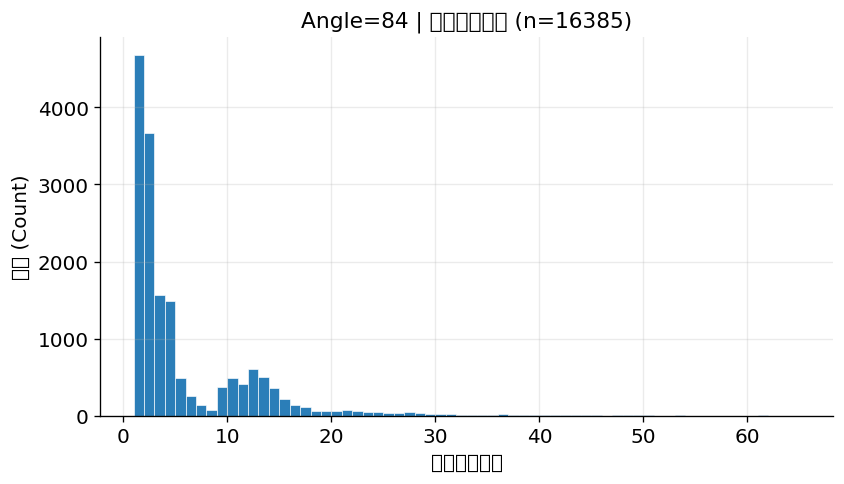

C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 23

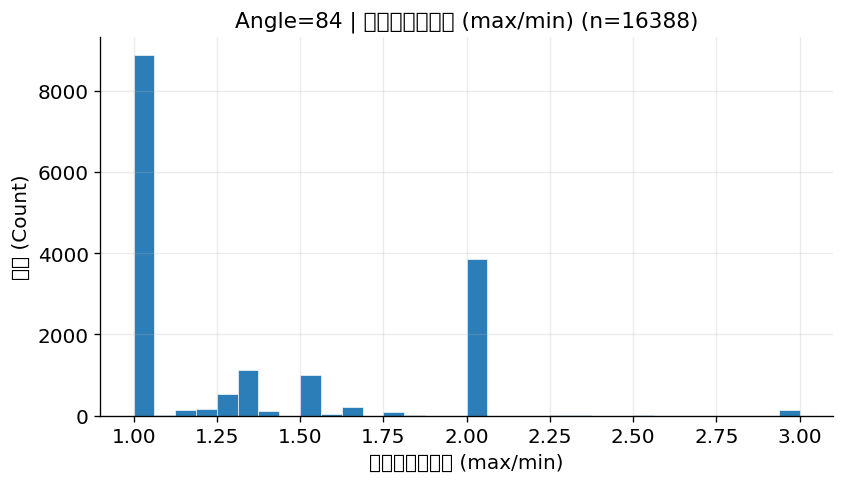

C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 27

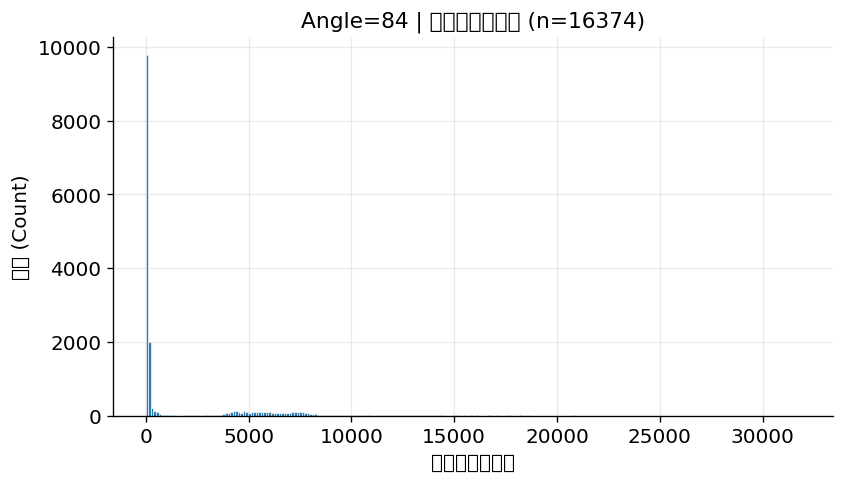

C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 22

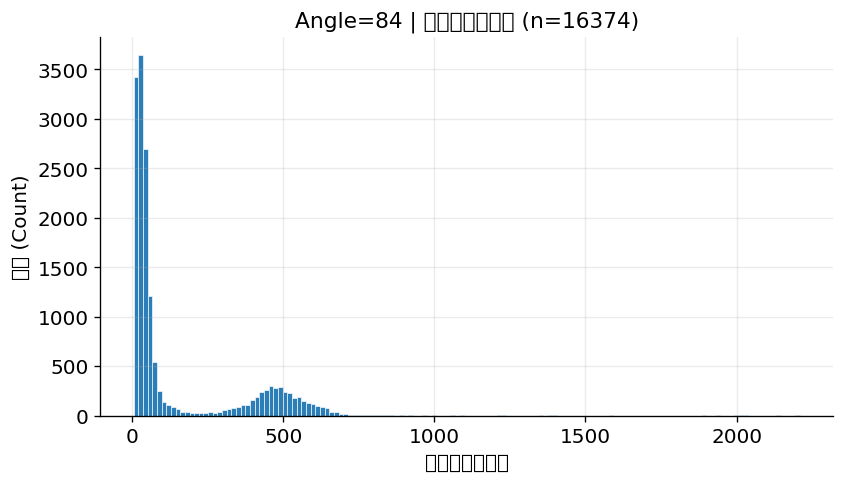

C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\27964\AppData\Local\Temp\ipykernel_12864\2611504614.py:297: UserWarning: Glyph 25

Saved plots: angle=84 -> E:\C1Analysis\C84_analysis_output\angle=84\plots


In [27]:
def process_one_angle(angle_dir: Path) -> dict:
    if CFG.USE_PARALLEL:
        return process_angle_parallel(angle_dir)
    return process_angle_sequential(angle_dir)


def generate_csv_all_angles():
    """阶段 1：生成/补齐 CSV（耗时）。只做特征计算与写盘，不做绘图。"""
    angle_dirs = iter_angle_dirs(CFG.DATA_ROOT)
    print("角度目录数量:", len(angle_dirs))

    run_log = {
        "config": {k: (str(v) if isinstance(v, Path) else v) for k, v in CFG.__dict__.items()},
        "angles": [],
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    results = []
    for angle_dir in angle_dirs:
        res = process_one_angle(angle_dir)
        results.append(res)
        run_log["angles"].append(res)
        print(res)

    log_path = CFG.OUT_DIR / "run_log.json"
    log_path.write_text(json.dumps(run_log, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Run log saved:", log_path)
    return results


def run_all_angles():
    """旧入口：现在仅等价于生成 CSV。建议改用 generate_csv_all_angles()."""
    return generate_csv_all_angles()


# 注意：不再默认自动全量运行。
# 你可以按第 9 节说明手动运行：
generate_csv_all_angles()
summary_df = build_angle_summary()
show_plots()
save_plots()